<a href="https://colab.research.google.com/github/mamontoff2018-lgtm/google-colab/blob/main/MO5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from __future__ import division, print_function
%matplotlib inline
from matplotlib import pyplot as plt
import seaborn as sns
import pickle
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression

In [3]:
train_df = pd.read_csv('train_sessions.csv', index_col='session_id')
test_df = pd.read_csv('test_sessions.csv', index_col='session_id')

times = ['time%s' % i for i in range(1, 11)]
train_df[times] = train_df[times].apply(pd.to_datetime)
test_df[times] = test_df[times].apply(pd.to_datetime)
train_df = train_df.sort_values(by='time1')

print(train_df.shape)
print(test_df.shape)
train_df.head()

(253561, 21)
(82797, 20)


,site1,time1,site2,time2,site3,time3,site4,time4,site5,time5,...,time6,site7,time7,site8,time8,site9,time9,site10,time10,target
session_id,,,,,,,,,,,,,,,,,,,,,
21669,56,2013-01-12 08:05:57,55.0,2013-01-12 08:05:57,NaN,NaT,NaN,NaT,NaN,NaT,...,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,0
54843,56,2013-01-12 08:37:23,55.0,2013-01-12 08:37:23,56.0,2013-01-12 09:07:07,55.0,2013-01-12 09:07:09,NaN,NaT,...,NaT,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,0
77292,946,2013-01-12 08:50:13,946.0,2013-01-12 08:50:14,951.0,2013-01-12 08:50:15,946.0,2013-01-12 08:50:15,946.0,2013-01-12 08:50:16,...,2013-01-12 08:50:16,948.0,2013-01-12 08:50:16,784.0,2013-01-12 08:50:16,949.0,2013-01-12 08:50:17,946.0,2013-01-12 08:50:17,0
114021,945,2013-01-12 08:50:17,948.0,2013-01-12 08:50:17,949.0,2013-01-12 08:50:18,948.0,2013-01-12 08:50:18,945.0,2013-01-12 08:50:18,...,2013-01-12 08:50:18,947.0,2013-01-12 08:50:19,945.0,2013-01-12 08:50:19,946.0,2013-01-12 08:50:19,946.0,2013-01-12 08:50:20,0
146670,947,2013-01-12 08:50:20,950.0,2013-01-12 08:50:20,948.0,2013-01-12 08:50:20,947.0,2013-01-12 08:50:21,950.0,2013-01-12 08:50:21,...,2013-01-12 08:50:21,946.0,2013-01-12 08:50:21,951.0,2013-01-12 08:50:22,946.0,2013-01-12 08:50:22,947.0,2013-01-12 08:50:22,0


In [5]:
sites = ['site%s' % i for i in range(1, 11)]
train_df[sites] = train_df[sites].fillna(0).astype('int')
test_df[sites] = test_df[sites].fillna(0).astype('int')
with open(r"site_dic.pkl", "rb") as input_file:
    site_dict = pickle.load(input_file)
sites_dict = pd.DataFrame(list(site_dict.keys()),
                          index=list(site_dict.values()),
                          columns=['site'])
print(u'всего сайтов:', sites_dict.shape[0])
sites_dict.head()

всего сайтов: 48371


,site
25075,www.abmecatronique.com
13997,groups.live.com
42436,majeureliguefootball.wordpress.com
30911,cdt46.media.tourinsoft.eu
8104,www.hdwallpapers.eu


In [7]:
top_sites = pd.Series(train_df[sites].fillna(0).values.flatten()) \
    .value_counts().sort_values(ascending=False).head(5)
print(top_sites)
sites_dict.iloc[top_sites.index]

21     123776
0      122730
23      87619
782     77055
22      58258
Name: count, dtype: int64


,site
5671,www.pacajob.com
25075,www.abmecatronique.com
7104,cbv.sfr.bench.cedexis.com
39605,cid-d6bf976dfdf5d212.users.storage.live.com
32074,mathaa.epfl.ch


In [8]:
#отдельный датафрейм
time_df = pd.DataFrame(index=train_df.index)
time_df['target'] = train_df['target']

# найдем время начала и окончания сессии
time_df['min'] = train_df[times].min(axis=1)
time_df['min'] = pd.to_datetime(time_df['min'])
time_df['max'] = train_df[times].max(axis=1)
time_df['max'] = pd.to_datetime(time_df['max'])

# вычислим длительность сессии и переведем в секунды
time_df['seconds'] = (time_df['max'].values - time_df['min'].values) / np.timedelta64(1, 's')
time_df.head()

,target,min,max,seconds
session_id,,,,
21669,0,2013-01-12 08:05:57,2013-01-12 08:05:57,0.0
54843,0,2013-01-12 08:37:23,2013-01-12 09:07:09,1786.0
77292,0,2013-01-12 08:50:13,2013-01-12 08:50:17,4.0
114021,0,2013-01-12 08:50:17,2013-01-12 08:50:20,3.0
146670,0,2013-01-12 08:50:20,2013-01-12 08:50:22,2.0


In [9]:
#целевая переменная
y_train = train_df['target']
# объединенная таблица исходных данных
full_df = pd.concat([train_df.drop('target', axis=1), test_df])
# индекс, по которому будем отделять обучающую выборку от тестовой
idx_split = train_df.shape[0]
print('y_train', y_train.shape)
print('train_df', train_df.shape)
print('full_df', full_df.shape)

y_train (253561,)
train_df (253561, 21)
full_df (336358, 20)


In [10]:
full_sites = full_df[sites]
full_sites.head()

,site1,site2,site3,site4,site5,site6,site7,site8,site9,site10
session_id,,,,,,,,,,
21669,56,55,0,0,0,0,0,0,0,0
54843,56,55,56,55,0,0,0,0,0,0
77292,946,946,951,946,946,945,948,784,949,946
114021,945,948,949,948,945,946,947,945,946,946
146670,947,950,948,947,950,952,946,951,946,947


In [11]:
sites_flatten = full_sites.values.flatten()
full_sites_sparse = csr_matrix((np.ones(sites_flatten.shape[0]),
                                sites_flatten,
                                range(0, sites_flatten.shape[0] + 10, 10)))[:, 1:]
print('sites_flatten', sites_flatten.shape)
print('full_sites_sparse', full_sites_sparse.shape)
print('Calculation Memory Size: ', full_sites_sparse.shape[0] * full_sites_sparse.shape[0] * 4)

# Сколько места занимает разреженная матрица в памяти
print('{} elements * {} bytes = {} bytes'.format(
    full_sites_sparse.count_nonzero(), 4, full_sites_sparse.count_nonzero() * 4))
print('Real Memory Size = {} bytes'.format(full_sites_sparse.data.nbytes))

sites_flatten (3363580,)
full_sites_sparse (336358, 48371)
Calculation Memory Size:  452546816656
1866898 elements * 4 bytes = 7467592 bytes
Real Memory Size = 14935184 bytes


In [14]:
def get_auc_lr_valid(X, y, C=1.0, seed=17, ratio = 0.9):
    idx = int(round(X.shape[0] * ratio))
    lr = LogisticRegression(C=C, random_state=seed, n_jobs=-1).fit(X[:idx, :], y[:idx])
    y_pred = lr.predict_proba(X[idx:, :])[:, 1]
    score = roc_auc_score(y[idx:], y_pred)
    return score

%time
X_train = full_sites_sparse[:idx_split, :]
print(get_auc_lr_valid(X_train, y_train))

CPU times: user 4 µs, sys: 1e+03 ns, total: 5 µs
Wall time: 8.34 µs
0.9201155656275813


In [15]:
# функция для записи прогнозов в файл
def write_to_submission_file(predicted_labels, out_file, target='target', index_label="session_id"):
    predicted_df = pd.DataFrame(predicted_labels,
                                index = np.arange(1, predicted_labels.shape[0] + 1),
                                columns=[target])
    predicted_df.to_csv(out_file, index_label=index_label)

%time
lr = LogisticRegression(C=1.0, random_state=17).fit(X_train, y_train)
X_test = full_sites_sparse[idx_split:, :]
y_test = lr.predict_proba(X_test)[:, 1]
write_to_submission_file(y_test, 'baseline_sites.csv')

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 4.77 µs


In [16]:
# датафрейм для анализа новых признаков
full_newFeat = pd.DataFrame(index=full_df.index)

full_newFeat['start_month'] = full_df['time1'].apply(lambda ts: 100 * ts.year + ts.month)
full_newFeat.head()

,start_month
session_id,
21669,201301
54843,201301
77292,201301
114021,201301
146670,201301


In [26]:
# добавляем новый признак в разреженную матрицу
print('full_newFeat.shape', full_newFeat.shape)
tmp = full_newFeat['start_month'].values.reshape(-1, 1)
print('tmp.shape', tmp.shape)
print('full_sites_sparse.shape', full_sites_sparse.shape)
X_train = csr_matrix(hstack([full_sites_sparse[:idx_split,:], tmp[:idx_split,:]]))
print(get_auc_lr_valid(X_train, y_train))

full_newFeat.shape (336358, 1)
tmp.shape (336358, 1)
full_sites_sparse.shape (336358, 48371)
0.8772012177006797


In [27]:
# добавим новый стандартизированный признак в разреженную матрицу
tmp = StandardScaler().fit_transform(full_newFeat[['start_month']])
X_train = csr_matrix(hstack([full_sites_sparse[:idx_split,:], tmp[:idx_split,:]]))
print(get_auc_lr_valid(X_train, y_train))

0.9183907010081689


In [29]:
# масштабируем новый признак
full_newFeat['n_unique_sites'] = (full_sites.values > 0).sum(1)
tmp = StandardScaler().fit_transform(full_newFeat[['start_month', 'n_unique_sites']])
X_train = csr_matrix(hstack([full_sites_sparse[:idx_split,:], tmp[:idx_split,:]]))
print('X_train shape', X_train.shape)
# обучение, ошибка
print(get_auc_lr_valid(X_train, y_train))

X_train shape (253561, 48373)
0.9170461036718209


In [30]:
full_newFeat['start_hour'] = time_df['min'].dt.hour
full_newFeat['morning'] = (full_newFeat['start_hour'] <= 11).astype(np.int32)
full_newFeat

,start_month,n_unique_sites,start_hour,morning
session_id,,,,
21669,201301,2,8,1
54843,201301,4,8,1
77292,201301,10,8,1
114021,201301,10,8,1
146670,201301,10,8,1
...,...,...,...,...
82793,201410,3,8,1
82794,201405,10,8,1
82795,201405,10,13,0


In [31]:
%time
#обучающая выборка
tmp_scaled = StandardScaler().fit_transform(full_newFeat[['start_month', 'start_hour', 'morning']])
X_train = csr_matrix(hstack([full_sites_sparse[:idx_split,:], tmp_scaled[:idx_split,:]]))
# зафиксируем качество с параметрами по умолчанию
score_C_1 = get_auc_lr_valid(X_train, y_train)
print(score_C_1)

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 7.63 µs
0.9587936846948684


In [33]:
%time
# набор возможных значений C
Cs = np.logspace(-3, 1, 10)
scores = []
for C in Cs:
    sc = get_auc_lr_valid(X_train, y_train, C=C)
    scores.append(sc)
    print(C, ' -> ', sc)
np.max(scores)

CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 4.77 µs
0.001  ->  0.9354606110120816
0.0027825594022071257  ->  0.9429379429155254
0.007742636826811269  ->  0.9508529067576772
0.021544346900318832  ->  0.957238649648083
0.05994842503189409  ->  0.9595290090044395
0.1668100537200059  ->  0.9609433496852793
0.46415888336127775  ->  0.9590786964576419
1.2915496650148828  ->  0.9578421862092953
3.593813663804626  ->  0.9569472975812646
10.0  ->  0.9532444090595096


np.float64(0.9609433496852793)

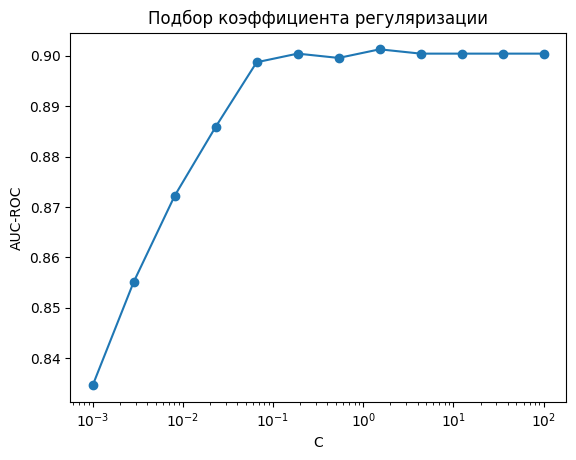

In [67]:
plt.plot(Cs, scores, 'o-')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('AUC-ROC')
plt.title('Подбор коэффициента регуляризации')
plt.show()

In [38]:
score_result = get_auc_lr_valid(X_train, y_train, C=0.1668101)
print(score_result)

0.9609433496852794


In [39]:
tmp_scaled = StandardScaler().fit_transform(full_newFeat[['start_month', 'start_hour', 'morning']])
X_train = csr_matrix(hstack([full_sites_sparse[:idx_split,:], tmp_scaled[:idx_split,:]]))
X_test = csr_matrix(hstack([full_sites_sparse[idx_split:,:], tmp_scaled[idx_split:,:]]))
# обучим модель на всей выборке с оптимальным коэффициентом регуляризации
lr = LogisticRegression(C=0.1668101, random_state=17).fit(X_train, y_train)
y_test = lr.predict_proba(X_test)[:, 1]
write_to_submission_file(y_test, 'baseline_res.csv')

In [ ]:
import pandas as pd
df = pd.read_csv('train.csv')
print(df.shape)
print(df.info())
df.head()

In [53]:
y = df['Survived']
X = df.drop(['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin'], axis=1)
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [54]:
X['FamilySize'] = X['SibSp'] + X['Parch'] + 1
X['IsAlone'] = (X['FamilySize'] == 1).astype(int)

# Заполнение пропусков
X['Age'] = X['Age'].fillna(X['Age'].median())
X['Fare'] = X['Fare'].fillna(X['Fare'].median())
X['Embarked'] = X['Embarked'].fillna('S')

X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,3,male,22.0,1,0,7.2500,S,2,0
1,1,female,38.0,1,0,71.2833,C,2,0
2,3,female,26.0,0,0,7.9250,S,1,1
3,1,female,35.0,1,0,53.1000,S,2,0
4,3,male,35.0,0,0,8.0500,S,1,1


In [55]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

cat_features = ['Pclass', 'Sex', 'Embarked']
num_features = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize', 'IsAlone']

X_cat = pd.get_dummies(X[cat_features], drop_first=True)
X_num = X[num_features]

scaler = StandardScaler()
X_num_scaled = pd.DataFrame(scaler.fit_transform(X_num),
                            columns=X_num.columns, index=X_num.index)

X_prepared = pd.concat([X_num_scaled, X_cat], axis=1)
print('X_prepared.shape:', X_prepared.shape)
X_prepared.head()

X_prepared.shape: (891, 10)


,Age,Fare,SibSp,Parch,FamilySize,IsAlone,Pclass,Sex_male,Embarked_Q,Embarked_S
0,-0.565736,-0.502445,0.432793,-0.473674,0.059160,-1.231645,3,True,False,True
1,0.663861,0.786845,0.432793,-0.473674,0.059160,-1.231645,1,False,False,False
2,-0.258337,-0.488854,-0.474545,-0.473674,-0.560975,0.811922,3,False,False,True
3,0.433312,0.420730,0.432793,-0.473674,0.059160,-1.231645,1,False,False,True
4,0.433312,-0.486337,-0.474545,-0.473674,-0.560975,0.811922,3,True,False,True


In [56]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X_prepared.values, y.values,
    test_size=0.2, random_state=17, stratify=y
)
print(X_train.shape, X_val.shape)

(712, 10) (179, 10)


In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

def get_auc_lr_valid(X, y, C=1.0, seed=17, ratio=0.9):
    idx = int(round(X.shape[0] * ratio))
    lr = LogisticRegression(C=C, random_state=seed, max_iter=200).fit(X[:idx, :], y[:idx])
    y_pred = lr.predict_proba(X[idx:, :])[:, 1]
    return roc_auc_score(y[idx:], y_pred)
# Только базовые признаки
auc_base = get_auc_lr_valid(X_train[:, :8], y_train)          # 8 исходных числовых + категориальных
print('Базовые признаки: AUC =', auc_base)

# + 1 синтезированный признак
auc_one = get_auc_lr_valid(X_train[:, :9], y_train)
print('1 синтезированный признак: AUC =', auc_one)

# + 2 синтезированных признака
auc_two = get_auc_lr_valid(X_train, y_train)
print('2 синтезированных признака: AUC =', auc_two)

Базовые признаки: AUC = 0.8952991452991453
1 синтезированный признак: AUC = 0.8961538461538463
2 синтезированных признака: AUC = 0.9012820512820513


In [60]:
import numpy as np
Cs = np.logspace(-3, 2, 12)
scores = []
for C in Cs:
    sc = get_auc_lr_valid(X_train, y_train, C=C)
    scores.append(sc)
    print(f'C = {C:.8f} → AUC = {sc:.8f}')

C = 0.00100000 → AUC = 0.83461538
C = 0.00284804 → AUC = 0.85512821
C = 0.00811131 → AUC = 0.87222222
C = 0.02310130 → AUC = 0.88589744
C = 0.06579332 → AUC = 0.89871795
C = 0.18738174 → AUC = 0.90042735
C = 0.53366992 → AUC = 0.89957265
C = 1.51991108 → AUC = 0.90128205
C = 4.32876128 → AUC = 0.90042735
C = 12.32846739 → AUC = 0.90042735
C = 35.11191734 → AUC = 0.90042735
C = 100.00000000 → AUC = 0.90042735


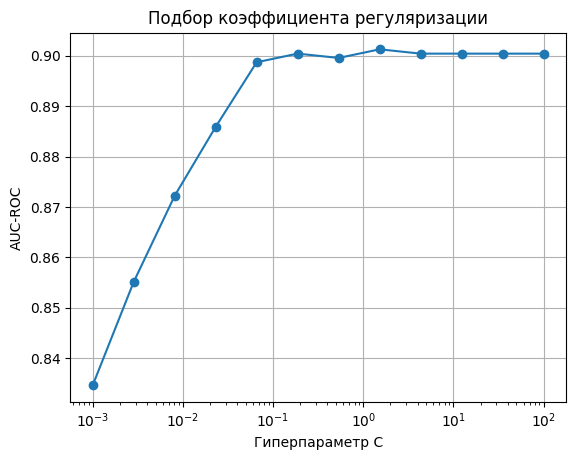

In [61]:
import matplotlib.pyplot as plt
plt.plot(Cs, scores, 'o-')
plt.xscale('log')
plt.xlabel('Гиперпараметр C')
plt.ylabel('AUC-ROC')
plt.title('Подбор коэффициента регуляризации')
plt.grid(True)
plt.show()

In [65]:
best_C = 1.51991108

final_model = LogisticRegression(C=best_C, random_state=17, max_iter=200)
final_model.fit(X_train, y_train)

test_df = pd.read_csv('test.csv')

test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1
test_df['IsAlone'] = (test_df['FamilySize'] == 1).astype(int)

test_df['Age'] = test_df['Age'].fillna(test_df['Age'].median())
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())
test_df['Embarked'] = test_df['Embarked'].fillna('S')

cat_features = ['Pclass', 'Sex', 'Embarked']
num_features = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize', 'IsAlone']

X_test_cat = pd.get_dummies(test_df[cat_features], drop_first=True)
X_test_num = test_df[num_features]

X_test_num_scaled = pd.DataFrame(scaler.transform(X_test_num),
                                 columns=X_test_num.columns,
                                 index=X_test_num.index)

X_test_prepared = pd.concat([X_test_num_scaled, X_test_cat], axis=1)

#Делаем предсказание
y_test_pred = final_model.predict_proba(X_test_prepared.values)[:, 1]

#Создаём submission
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': (y_test_pred > 0.5).astype(int)
})

submission.to_csv('baseline_titanic.csv', index=False)

print('Бейслайн успешно сохранён в файл baseline_titanic.csv')


Бейслайн успешно сохранён в файл baseline_titanic.csv


In [76]:
import pandas as pd
train_df = pd.read_csv('train_sessions.csv', index_col='session_id')
train_df['time1'] = pd.to_datetime(train_df['time1'])
test_df = pd.read_csv('test_sessions.csv', index_col='session_id')
test_df['time1'] = pd.to_datetime(test_df['time1'])
print(train_df['time1'].dt.year.value_counts())
print(test_df['time1'].dt.year.value_counts())

time1
2014    178886
2013     74675
Name: count, dtype: int64
time1
2014    82797
Name: count, dtype: int64


In [79]:
sites = ['site%s' % i for i in range(1, 11)]
alice_mask = train_df['target'] == 1
top_alice_sites = pd.Series(train_df[alice_mask][sites].values.flatten()) \
    .value_counts().head(10)

sites_dict = pd.read_pickle('site_dic.pkl')
top_sites_names = pd.DataFrame(list(sites_dict.items()),
                               columns=['site', 'id']).set_index('id')
print(top_alice_sites)
print(top_sites_names.loc[top_alice_sites.index])

77.0     1382
80.0     1354
76.0     1307
29.0      897
21.0      857
81.0      609
879.0     522
22.0      522
75.0      451
82.0      447
Name: count, dtype: int64
                                     site
77                           i1.ytimg.com
80                          s.youtube.com
76                        www.youtube.com
29                       www.facebook.com
21                          www.google.fr
81   r4---sn-gxo5uxg-jqbe.googlevideo.com
879  r1---sn-gxo5uxg-jqbe.googlevideo.com
22                        apis.google.com
75                            s.ytimg.com
82   r2---sn-gxo5uxg-jqbe.googlevideo.com


In [84]:
times = ['time%s' % i for i in range(1, 11)]
train_df[times] = train_df[times].apply(pd.to_datetime)

time_df = pd.DataFrame(index=train_df.index)
time_df['target'] = train_df['target']

time_df['seconds'] = (
    train_df[times].max(axis=1) - train_df[times].min(axis=1)
) / np.timedelta64(1, 's')

alice = time_df[time_df['target'] == 1]['seconds']
others = time_df[time_df['target'] == 0]['seconds']

print("1. Средняя длительность сессии Элис короче?")
print(alice.mean() < others.mean())

print("\n2. Доля сессий Элис > 1%?")
print(train_df['target'].mean() > 0.01)

print("\n3. Диапазоны длительности примерно одинаковые?")
print("Элис:   min =", alice.min(), " max =", alice.max(), " std =", alice.std())
print("Другие: min =", others.min(), " max =", others.max(), " std =", others.std())

print("\n4. Доля сессий Элис ≥ 40 сек < 25%?")
print((alice >= 40).mean() < 0.25)

1. Средняя длительность сессии Элис короче?
True

2. Доля сессий Элис > 1%?
False

3. Диапазоны длительности примерно одинаковые?
Элис:   min = 0.0  max = 1763.0  std = 153.30901405274324
Другие: min = 0.0  max = 1800.0  std = 296.65351771851175

4. Доля сессий Элис ≥ 40 сек < 25%?
True


/tmp/ipykernel_676/3254817858.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  alice_month = full_newFeat[train_df['target'] == 1]['start_month'].value_counts().sort_index()


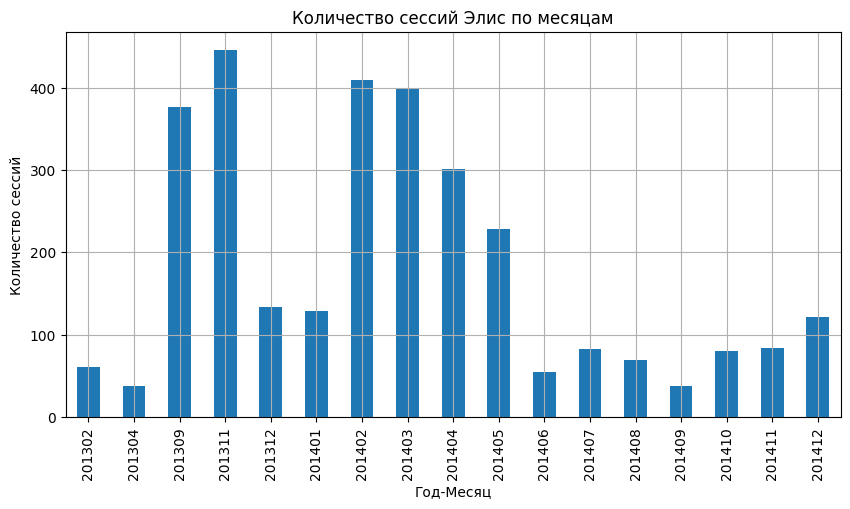

In [85]:
full_newFeat['start_month'] = full_df['time1'].apply(lambda ts: 100 * ts.year + ts.month)
alice_month = full_newFeat[train_df['target'] == 1]['start_month'].value_counts().sort_index()

plt.figure(figsize=(10,5))
alice_month.plot(kind='bar')
plt.title('Количество сессий Элис по месяцам')
plt.xlabel('Год-Месяц')
plt.ylabel('Количество сессий')
plt.grid(True)
plt.show()